In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from scipy.stats import pearsonr
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.preprocessing import OneHotEncoder
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression

print("✓ Tools loaded successfully!")

✓ Tools loaded successfully!


In [153]:
print("""This presentation will focus on World Happiness and its Determining Factors, mainly Working Hours!
I wanted to see if I could support the well-known hypothesis that happier countries are those that work fewer hours;
Iceland, one of the happiest countries in happiness rankings, has a four day work week. So it seemed like an obvious correlation.""")
print()
print("""Of course, this wont account for hours worked that are unreported; this may be undocumented work, jobs that are 
traditionally off-the-books like babysitting, landscaping (which also overlaps from undocumented work), etc. And yes, there 
are other reasons why these countries are happier than ones with more working hours, but I do think this holds some weight in that 
assessment. Work culture most likely determines other cultural norms or atittudes on living and wellbeing.""")

This presentation will focus on World Happiness and its Determining Factors, mainly Working Hours!
I wanted to see if I could support the well-known hypothesis that happier countries are those that work fewer hours;
Iceland, one of the happiest countries in happiness rankings, has a four day work week. So it seemed like an obvious correlation.

Of course, this wont account for hours worked that are unreported; this may be undocumented work, jobs that are 
traditionally off-the-books like babysitting, landscaping (which also overlaps from undocumented work), etc. And yes, there 
are other reasons why these countries are happier than ones with more working hours, but I do think this holds some weight in that 
assessment. Work culture most likely determines other cultural norms or atittudes on living and wellbeing.


In [18]:
worhapp = pd.read_csv("WHR2023.csv") # wont be using it now but keeping it here for process visibility 
hours = pd.read_csv("workinghoursperpersonemployed.csv")
# citing this data: OECD - Productivity - Level of GDP per capita and productivity – processed by Our World in Data. 
# “Average hours worked per person employed” [dataset]. OECD - Productivity - Level of GDP per capita and productivity [original data]. 
# Source: OECD - Productivity - Level of GDP per capita and productivity – processed by Our World In Data
hoursgdp = pd.read_csv("workinghoursvsgdppercapita.csv")
# Feenstra et al. - Penn World Table (2025) – with major processing by Our World in Data. 
# “GDP per capita – Penn World Table – In constant international-$” [dataset]. Feenstra et al., “Penn World Table 11.0” [original data]. 
# Source: Feenstra et al. - Penn World Table (2025) – with major processing by Our World In Data

# worhapp.head(), hours.head(), hoursgdp.head() - tried it this way...did not like the way the output looked

In [24]:
worhapp_2016 = pd.read_csv("worldhappiness2016.csv") # dataset from the year that is consistent across all datasets 
# Sustainable Development Solutions Network. (2016). World Happiness Report 2016 [Data set]. 
# Kaggle. https://www.kaggle.com/datasets/unsdsn/world-happiness
worhapp_2016.head()

,Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Denmark,Western Europe,1,7.526,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939
1,Switzerland,Western Europe,2,7.509,7.428,7.590,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463
2,Iceland,Western Europe,3,7.501,7.333,7.669,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678,2.83137
3,Norway,Western Europe,4,7.498,7.421,7.575,1.57744,1.12690,0.79579,0.59609,0.35776,0.37895,2.66465
4,Finland,Western Europe,5,7.413,7.351,7.475,1.40598,1.13464,0.81091,0.57104,0.41004,0.25492,2.82596


In [14]:
hours.head()

,Entity,Code,Year,Subject:Average hours worked per person employed - PDB_LV
0,Australia,AUS,1970,1864.935951
1,Australia,AUS,1971,1847.040484
2,Australia,AUS,1972,1827.516925
3,Australia,AUS,1973,1814.705069
4,Australia,AUS,1974,1831.279122


In [31]:
# for average working hours per person employed, i wanted to focus mainly on 2016 data
# i'm isolating for this year since the world happiness report data i was using is from 2016
# i actually tried doing this with the 2023 whr first but the working hours data only went up to 2016

hours = pd.read_csv("workinghoursperpersonemployed.csv")
hours_2016 = hours[hours["Year"] == 2016]
hours_2016.head()

,Entity,Code,Year,Subject:Average hours worked per person employed - PDB_LV
46,Australia,AUS,2016,1731.267922
68,Austria,AUT,2016,1609.352282
115,Belgium,BEL,2016,1545.815032
162,Canada,CAN,2016,1702.967177
193,Chile,CHL,2016,1974.000000


In [23]:
# quick check ( success! )
hours_2016["Year"].unique()

array([2016])

In [36]:
hoursgdp.head()

# as you can see...this dataset starts at like BCE or something and i have a lot of NaN values i'm not sure how to fix
# so...we're sticking to two datasets now!

,Entity,Code,Year,Average working hours per worker,"GDP per capita (output, multiple price benchmarks)",Population (historical),World region according to OWID
0,Afghanistan,AFG,-10000,NaN,NaN,14737.0,NaN
1,Afghanistan,AFG,-9000,NaN,NaN,20405.0,NaN
2,Afghanistan,AFG,-8000,NaN,NaN,28253.0,NaN
3,Afghanistan,AFG,-7000,NaN,NaN,39120.0,NaN
4,Afghanistan,AFG,-6000,NaN,NaN,54166.0,NaN


In [37]:
hours_2016 = hours[hours["Year"] == 2016].copy()

In [57]:
worhapp_2016.rename(columns={"country": "Country", "happiness_score": "Happiness_Score"}, inplace=True)
hours_2016.rename(columns={"country": "Country", "Subject:Average hours worked per person employed - PDB_LV": "Working_Hours"}, inplace=True)

In [55]:
worhapp_2016.head()

,Country,Region,Happiness Rank,Happiness_Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Denmark,Western Europe,1,7.526,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939
1,Switzerland,Western Europe,2,7.509,7.428,7.590,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463
2,Iceland,Western Europe,3,7.501,7.333,7.669,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678,2.83137
3,Norway,Western Europe,4,7.498,7.421,7.575,1.57744,1.12690,0.79579,0.59609,0.35776,0.37895,2.66465
4,Finland,Western Europe,5,7.413,7.351,7.475,1.40598,1.13464,0.81091,0.57104,0.41004,0.25492,2.82596


In [172]:
worhapp_2016.describe()

,Happiness Rank,Happiness_Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000
mean,78.980892,5.382185,5.282395,5.481975,0.953880,0.793621,0.557619,0.370994,0.137624,0.242635,2.325807
std,45.466030,1.141674,1.148043,1.136493,0.412595,0.266706,0.229349,0.145507,0.111038,0.133756,0.542220
min,1.000000,2.905000,2.732000,3.078000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.817890
25%,40.000000,4.404000,4.327000,4.465000,0.670240,0.641840,0.382910,0.257480,0.061260,0.154570,2.031710
50%,79.000000,5.314000,5.237000,5.419000,1.027800,0.841420,0.596590,0.397470,0.105470,0.222450,2.290740
75%,118.000000,6.269000,6.154000,6.434000,1.279640,1.021520,0.729930,0.484530,0.175540,0.311850,2.664650
max,157.000000,7.526000,7.460000,7.669000,1.824270,1.183260,0.952770,0.608480,0.505210,0.819710,3.837720


In [170]:
hours_2016.head()

,Country,Code,Year,Working_Hours
46,Australia,AUS,2016,1731.267922
68,Austria,AUT,2016,1609.352282
115,Belgium,BEL,2016,1545.815032
162,Canada,CAN,2016,1702.967177
193,Chile,CHL,2016,1974.000000


In [171]:
hours_2016.describe()

,Year,Working_Hours
count,41.0,41.000000
mean,2016.0,1733.703069
std,0.0,187.747424
min,2016.0,1358.586553
25%,2016.0,1626.459160
50%,2016.0,1731.267922
75%,2016.0,1864.585390
max,2016.0,2143.379133


In [59]:
worhapp_2016.info()
worhapp_2016.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        157 non-null    object 
 1   Region                         157 non-null    object 
 2   Happiness Rank                 157 non-null    int64  
 3   Happiness_Score                157 non-null    float64
 4   Lower Confidence Interval      157 non-null    float64
 5   Upper Confidence Interval      157 non-null    float64
 6   Economy (GDP per Capita)       157 non-null    float64
 7   Family                         157 non-null    float64
 8   Health (Life Expectancy)       157 non-null    float64
 9   Freedom                        157 non-null    float64
 10  Trust (Government Corruption)  157 non-null    float64
 11  Generosity                     157 non-null    float64
 12  Dystopia Residual              157 non-null    flo

Country                          0
Region                           0
Happiness Rank                   0
Happiness_Score                  0
Lower Confidence Interval        0
Upper Confidence Interval        0
Economy (GDP per Capita)         0
Family                           0
Health (Life Expectancy)         0
Freedom                          0
Trust (Government Corruption)    0
Generosity                       0
Dystopia Residual                0
dtype: int64

In [60]:
hours_2016.info()
hours_2016.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 41 entries, 46 to 1567
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Country        41 non-null     object 
 1   Code           36 non-null     object 
 2   Year           41 non-null     int64  
 3   working_hours  41 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 1.6+ KB


Country          0
Code             5
Year             0
working_hours    0
dtype: int64

In [173]:
# alright, this will be my attempt to merge the data ( wish me luck! )
merged = pd.merge(
    worhapp_2016,
    hours_2016,
    on="Country",
    how="inner"  # this should keep only countries present in both datasets
)

hours_2016.rename(columns={"working_hours": "Working_Hours"}, inplace=True)

merged.head()

,Country,Region,Happiness Rank,Happiness_Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual,Code,Year,Working_Hours
0,Denmark,Western Europe,1,7.526,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939,DNK,2016,1408.963504
1,Switzerland,Western Europe,2,7.509,7.428,7.590,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463,CHE,2016,1589.675739
2,Iceland,Western Europe,3,7.501,7.333,7.669,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678,2.83137,ISL,2016,1883.000000
3,Norway,Western Europe,4,7.498,7.421,7.575,1.57744,1.12690,0.79579,0.59609,0.35776,0.37895,2.66465,NOR,2016,1429.450072
4,Finland,Western Europe,5,7.413,7.351,7.475,1.40598,1.13464,0.81091,0.57104,0.41004,0.25492,2.82596,FIN,2016,1634.943972


In [175]:
# removing 'Working_Hours' from its current position ( because it's placed at the end originally ) and i want it in front-ish
cols = merged.columns.tolist()

cols.remove('Working_Hours')

# inserting it after 'Happiness_Score' ( index 4? )
cols.insert(4, 'Working_Hours')

# reordering the dataset
merged = merged[cols]

merged.head()

,Country,Region,Happiness Rank,Happiness_Score,Working_Hours,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual,Code,Year
0,Denmark,Western Europe,1,7.526,1408.963504,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939,DNK,2016
1,Switzerland,Western Europe,2,7.509,1589.675739,7.428,7.590,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463,CHE,2016
2,Iceland,Western Europe,3,7.501,1883.000000,7.333,7.669,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678,2.83137,ISL,2016
3,Norway,Western Europe,4,7.498,1429.450072,7.421,7.575,1.57744,1.12690,0.79579,0.59609,0.35776,0.37895,2.66465,NOR,2016
4,Finland,Western Europe,5,7.413,1634.943972,7.351,7.475,1.40598,1.13464,0.81091,0.57104,0.41004,0.25492,2.82596,FIN,2016


In [176]:
merged[["Happiness_Score", "Working_Hours"]].describe()

,Happiness_Score,Working_Hours
count,35.000000,35.000000
mean,6.553743,1732.056465
std,0.807720,191.911952
min,5.033000,1358.586553
25%,5.845500,1617.905721
50%,6.778000,1731.267922
75%,7.302000,1873.792695
max,7.526000,2143.379133


In [177]:
# correlation
merged[["Happiness_Score", "Working_Hours"]].corr()

,Happiness_Score,Working_Hours
Happiness_Score,1.000000,-0.498114
Working_Hours,-0.498114,1.000000


In [205]:
print("""After running this correlation (which shows that there is, in fact, a negative correlation between happiness and 
working hours, I will proceed with a regression analysis which will allow us to estimate the weight/strength and statistical 
significance of this relationship...which already seems to align with my hypothesis, thankfully!""")

After running this correlation (which shows that there is, in fact, a negative correlation between happiness and 
working hours, I will proceed with a regression analysis which will allow us to estimate the weight/strength and statistical 
significance of this relationship...which already seems to align with my hypothesis, thankfully!


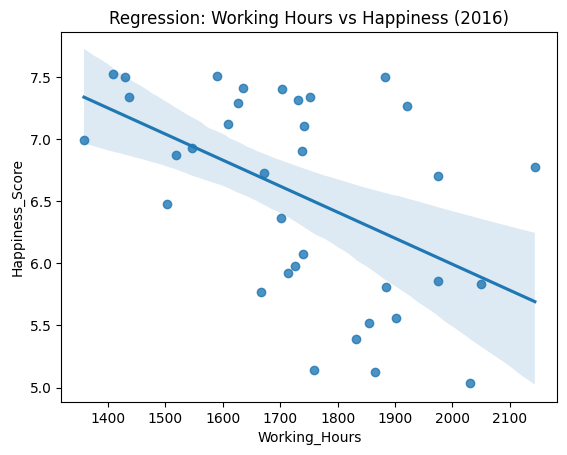

In [208]:
# but before that, I'd like to show a scatter plot with a simple regression line through it to better visualize this potential relationship
sb.regplot(
    data=merged,
    x="Working_Hours",
    y="Happiness_Score"
)
plt.title("Regression: Working Hours vs Happiness (2016)")
plt.show()

In [211]:
# and am now trying my hand at the OLS regression
X = merged["Working_Hours"]  # independent variable ( what we believe happiness will depend on ) 
y = merged["Happiness_Score"]  # dependent variable

# constant (intercept)
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        Happiness_Score   R-squared:                       0.248
Model:                            OLS   Adj. R-squared:                  0.225
Method:                 Least Squares   F-statistic:                     10.89
Date:                Thu, 18 Dec 2025   Prob (F-statistic):            0.00233
Time:                        17:07:32   Log-Likelihood:                -36.691
No. Observations:                  35   AIC:                             77.38
Df Residuals:                      33   BIC:                             80.49
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            10.1849      1.107      9.201      0.000       7.933      12.437
Working_Hours    -0.0021      0.001     -3.300      0.002      -0.003      -0.001
==============================================================================
Omnibus:                        3.359   Durbin-Watson:                   0.625
Prob(Omnibus):                  0.186   Jarque-Bera (JB):                1.522
Skew:                          -0.049   Prob(JB):                        0.467
Kurtosis:                       1.983   Cond. No.                     1.60e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.6e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [212]:
# i've been writing out my reports but want to try my hand at coding for a result so we can automate this!
# ...and so I can use it for other EDAs in the future

coef = model.params['Working_Hours']
pval = model.pvalues['Working_Hours']
r2 = model.rsquared

if pval < 0.05:
    significance = "statistically significant"
else:
    significance = "not statistically significant"

print(f"The slope coefficient for working hours is {coef:.3f}, which is {significance}.")
print(f"This means that for each additional working hour, happiness changes by about {coef:.4f} units on average.")
print(f"The R-squared of the model is {r2:.2f}, meaning the model explains {r2*100:.1f}% of the variance in happiness scores.")
print()
for cat in merged['hours_category'].unique():
    mean_val = merged[merged['hours_category']==cat]['Happiness_Score'].mean()
    print(f"Countries with {cat} working hours have an average happiness score of {mean_val:.2f}.")

print()
print("""Now, I'm putting this information together in paragraph form. It is important to note that this analysis identifies 
correlation and not causation; other factors such as income/GDP, health, and social support may also be responsible for influencing 
overall happiness outcomes. Beyond that, there are countless people who go unreported from under- or unrepresented groups.""")
print()
if pval < 0.01:
    sig_text = "highly statistically significant"
elif pval < 0.05:
    sig_text = "statistically significant"
else:
    sig_text = "not statistically significant"

direction = "decrease" if coef < 0 else "increase"

paragraph = (
    f"An Ordinary Least Squares (OLS) regression was conducted to examine the "
    f"relationship between annual working hours and happiness scores in 2016. "
    f"The results indicate a {sig_text} relationship between working hours and "
    f"happiness. Specifically, each additional hour worked per year is associated "
    f"with an average {direction} of {abs(coef):.4f} points in the happiness score. "
    f"The model explains approximately {r2*100:.1f}% of the variation in happiness "
    f"scores across countries."
)

print(paragraph)

The slope coefficient for working hours is -0.002, which is statistically significant.
This means that for each additional working hour, happiness changes by about -0.0021 units on average.
The R-squared of the model is 0.25, meaning the model explains 24.8% of the variance in happiness scores.

Countries with Low working hours have an average happiness score of 7.34.
Countries with Medium working hours have an average happiness score of 6.90.
Countries with High working hours have an average happiness score of 6.27.

Now, I'm putting this information together in paragraph form. It is important to note that this analysis identifies 
correlation and not causation; other factors such as income/GDP, health, and social support may also be responsible for influencing 
overall happiness outcomes. Beyond that, there are countless people who go unreported from under- or unrepresented groups.

An Ordinary Least Squares (OLS) regression was conducted to examine the relationship between annual wo

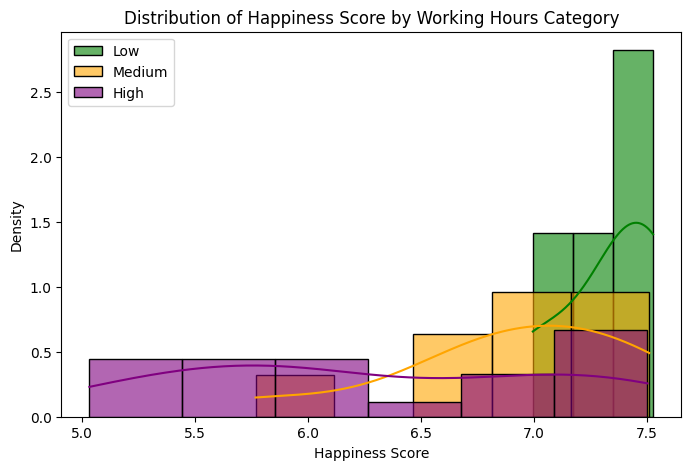

In [213]:
# so here, I want to try something I did before with histograms 
# basically, I want to categorize the working hours by amount ( low, medium, high )
# have a histogram for each category and super impose them one on top of the other

merged['hours_category'] = pd.cut(
    merged['Working_Hours'],
    bins=[1200, 1500, 1700, 2200],  
    labels=['Low', 'Medium', 'High']
)

# plot overlaid histograms
plt.figure(figsize=(8,5))

sb.histplot(
    merged[merged['hours_category'] == 'Low']['Happiness_Score'],
    color='green',
    label='Low',
    kde=True,
    stat='density',
    alpha=0.6
)

sb.histplot(
    merged[merged['hours_category'] == 'Medium']['Happiness_Score'],
    color='orange',
    label='Medium',
    kde=True,
    stat='density',
    alpha=0.6
)

sb.histplot(
    merged[merged['hours_category'] == 'High']['Happiness_Score'],
    color='purple',
    label='High',
    kde=True,
    stat='density',
    alpha=0.6
)

plt.title('Distribution of Happiness Score by Working Hours Category')
plt.xlabel('Happiness Score')
plt.ylabel('Density')
plt.legend()
plt.show()

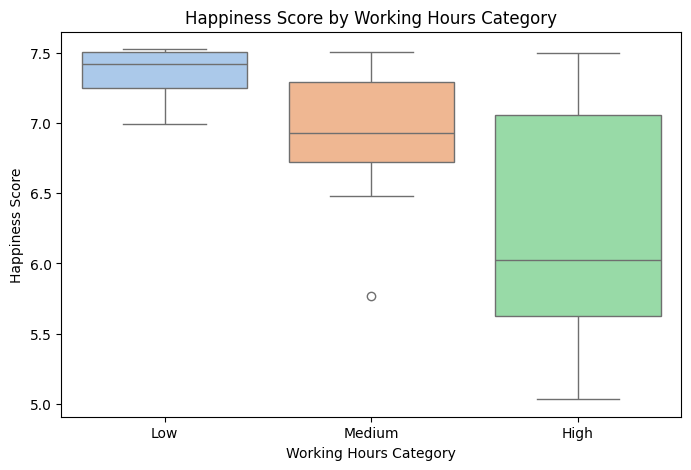

In [214]:
# and moving forward...this is me just trying out as many visualizations as I possibly can

plt.figure(figsize=(8,5))
sb.boxplot(data=merged, x='hours_category', y='Happiness_Score', hue='hours_category', palette='pastel', legend=False)
plt.title('Happiness Score by Working Hours Category')
plt.xlabel('Working Hours Category')
plt.ylabel('Happiness Score')
plt.show()

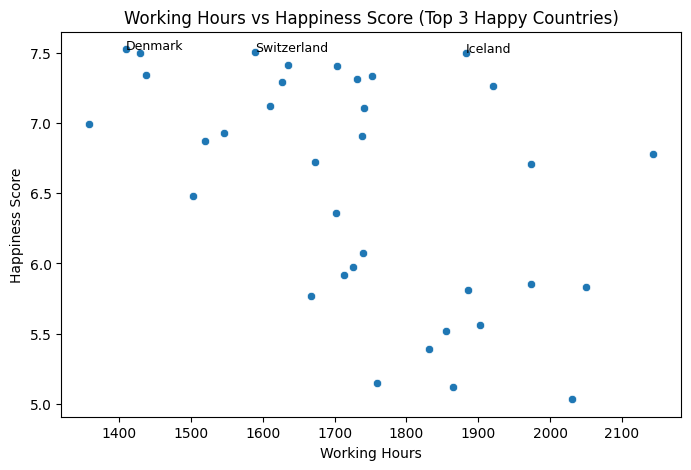

In [129]:
plt.figure(figsize=(8,5))
sb.scatterplot(data=merged, x='Working_Hours', y='Happiness_Score')
for i, row in merged.nlargest(3, 'Happiness_Score').iterrows():
    plt.text(row['Working_Hours'], row['Happiness_Score'], row['Country'], fontsize=9)
plt.title('Working Hours vs Happiness Score (Top 3 Happy Countries)')
plt.xlabel('Working Hours')
plt.ylabel('Happiness Score')
plt.show()

In [219]:
print("""As you can see with the graph above, the top three happiest countris are on the lower end in terms of working hours.
Of course, there are some outliers, and as I'd mentioned, other factors that influence happiness scores, but Denmark, ranking 
number one is on the lower end of the "working hours" spectrum and that supports my hypothesis to some extent, though not perfectly.""")

print()

print("""I also want to talk some about the outliers here...there are always outliers, and I'm really interested in seeing 
what makes those outliers different from the others...like which of the other factors, such as Economy (GDP per Capita),	
Family	Health (Life Expectancy),	Freedom	Trust (Government Corruption),	Generosity, and	Dystopia Residuals.""")

As you can see with the graph above, the top three happiest countris are on the lower end in terms of working hours.
Of course, there are some outliers, and as I'd mentioned, other factors that influence happiness scores, but Denmark, ranking 
number one is on the lower end of the "working hours" spectrum and that supports my hypothesis to some extent, though not perfectly.

I also want to talk some about the outliers here...there are always outliers, and I'm really interested in seeing 
what makes those outliers different from the others...like which of the other factors, such as Economy (GDP per Capita),	
Family	Health (Life Expectancy),	Freedom	Trust (Government Corruption),	Generosity, and	Dystopia Residuals.


In [228]:
high_happy = merged['Happiness_Score'].quantile(0.75)
low_happy = merged['Happiness_Score'].quantile(0.25)

high_hours = merged['Working_Hours'].quantile(0.75)
low_hours = merged['Working_Hours'].quantile(0.25)

In [229]:
happy_long_hours = merged[
    (merged['Happiness_Score'] >= high_happy) &
    (merged['Working_Hours'] >= high_hours)
]

happy_long_hours[['Country', 'Working_Hours', 'Happiness_Score']]

,Country,Working_Hours,Happiness_Score
2,Iceland,1883.0,7.501


In [237]:
unhappy_short_hours = merged[
    (merged['Happiness_Score'] <= low_happy) &
    (merged['Working_Hours'] <= low_hours)
]

unhappy_short_hours[['Country', 'Working_Hours', 'Happiness_Score']]

,Country,Working_Hours,Happiness_Score


In [243]:
print("""Super interestingly, it seems that there are no outlier countries with low working hours and low happiness scores!
To me, this suggests that countries with shorter average working hours don't tend to experience very low levels of happiness. 
This asymmetry boosts my hypothesis and the observed negative relationship between working hours and happiness rather than
contradicting it...I had actually though that there may be some outliers like this but an still interest in weighing other factors.""")

Super interestingly, it seems that there are no outlier countries with low working hours and low happiness scores!
To me, this suggests that countries with shorter average working hours don't tend to experience very low levels of happiness. 
This asymmetry boosts my hypothesis and the observed negative relationship between working hours and happiness rather than
contradicting it...I had actually though that there may be some outliers like this but an still interest in weighing other factors.


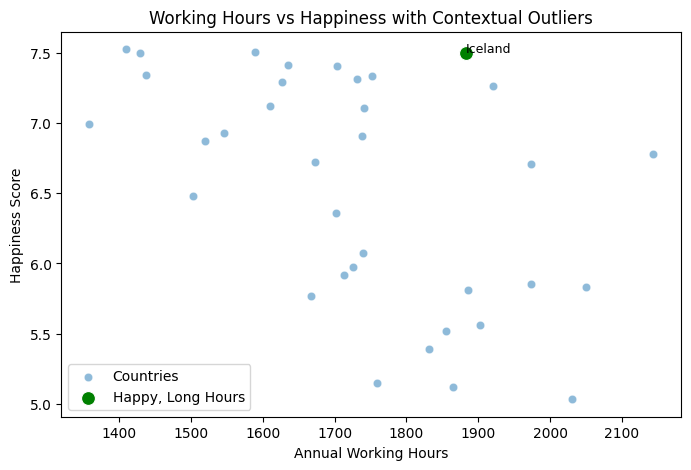

In [232]:
plt.figure(figsize=(8,5))

# base scatter plot 
sb.scatterplot(
    data=merged,
    x='Working_Hours',
    y='Happiness_Score',
    alpha=0.5,
    label='Countries'
)

# happy + long hours
sb.scatterplot(
    data=happy_long_hours,
    x='Working_Hours',
    y='Happiness_Score',
    color='green',
    s=100,
    label='Happy, Long Hours'
)

# unhappy + short hours
sb.scatterplot(
    data=unhappy_short_hours,
    x='Working_Hours',
    y='Happiness_Score',
    color='red',
    s=100,
    label='Unhappy, Short Hours'
)

# labeling
for _, row in pd.concat([happy_long_hours, unhappy_short_hours]).iterrows():
    plt.text(
        row['Working_Hours'],
        row['Happiness_Score'],
        row['Country'],
        fontsize=9
    )

plt.title('Working Hours vs Happiness with Contextual Outliers')
plt.xlabel('Annual Working Hours')
plt.ylabel('Happiness Score')
plt.legend()
plt.show()

In [244]:
# here i'm using the layout of the report that was given to us during class

def generate_happiness_report(df, filename="happiness_2016_report.txt"):
    lines = []
    lines.append("="*60)
    lines.append("WORLD HAPPINESS & WORKING HOURS REPORT (2016)")
    lines.append("="*60)
    lines.append(f"Generated: {datetime.now().strftime('%B %d, %Y at %I:%M %p')}")
    lines.append(f"Countries analyzed: {len(df)}")
    lines.append("")

    lines.append("KEY FINDINGS")
    lines.append("-"*40)

    # means by category
    lines.append("\n1. Average Happiness by Working Hours Category:")
    for cat in df['hours_category'].unique():
        mean_val = df[df['hours_category']==cat]['Happiness_Score'].mean()
        lines.append(f"   - {cat}: {mean_val:.2f}")

    # top 5 happiest countries
    lines.append("\n2. Top 5 Happiest Countries:")
    top5 = df.sort_values('Happiness_Score', ascending=False).head(5)
    for i, row in enumerate(top5.itertuples(), 1):
        lines.append(f"   {i}. {row.Country}: {row.Happiness_Score:.2f}")

    # regression summary
    lines.append("\n3. Regression Summary:")
    lines.append(f"   - Working hours coefficient: {coef:.4f}")
    lines.append(f"   - R-squared: {r2:.2f}")

    lines.append("\n" + "="*60)
    lines.append("END OF REPORT")

    report = "\n".join(lines)
    print(report)

    with open(filename, "w") as f:
        f.write(report)

    print(f"\n✓ Report saved as {filename}")
    return report

# generate report
report = generate_happiness_report(merged)

WORLD HAPPINESS & WORKING HOURS REPORT (2016)
Generated: December 18, 2025 at 05:40 PM
Countries analyzed: 35

KEY FINDINGS
----------------------------------------

1. Average Happiness by Working Hours Category:
   - Low: 7.34
   - Medium: 6.90
   - High: 6.27

2. Top 5 Happiest Countries:
   1. Denmark: 7.53
   2. Switzerland: 7.51
   3. Iceland: 7.50
   4. Norway: 7.50
   5. Finland: 7.41

3. Regression Summary:
   - Working hours coefficient: -0.0021
   - R-squared: 0.25

END OF REPORT

✓ Report saved as happiness_2016_report.txt


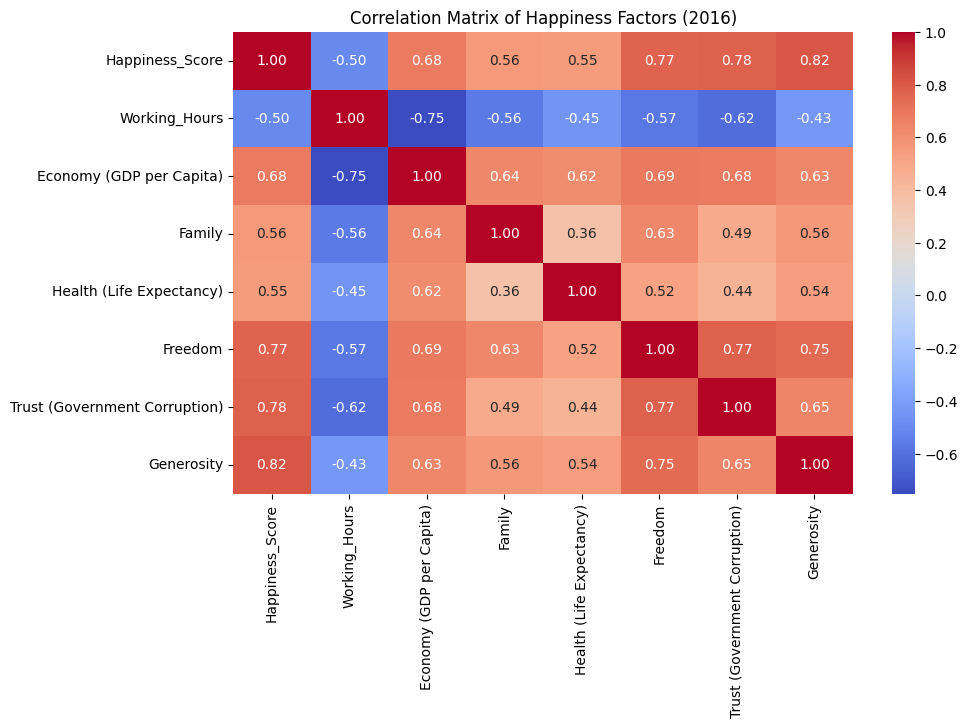

Strongest correlations with Happiness Score:

Generosity: 0.82
Trust (Government Corruption): 0.78
Freedom: 0.77
Economy (GDP per Capita): 0.68
Family: 0.56
Health (Life Expectancy): 0.55
Working_Hours: -0.50


In [245]:
plt.figure(figsize=(10,6))

corr = merged[[
    'Happiness_Score',
    'Working_Hours',
    'Economy (GDP per Capita)',
    'Family',
    'Health (Life Expectancy)',
    'Freedom',
    'Trust (Government Corruption)',
    'Generosity'
]].corr()

sb.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix of Happiness Factors (2016)")
plt.show()

import matplotlib.pyplot as plt
import seaborn as sb

# Select relevant columns
cols = [
    'Happiness_Score',
    'Working_Hours',
    'Economy (GDP per Capita)',
    'Family',
    'Health (Life Expectancy)',
    'Freedom',
    'Trust (Government Corruption)',
    'Generosity'
]

corr = merged[cols].corr()

# will this work? adding a text summary of strongest correlations with Happiness_Score
print("Strongest correlations with Happiness Score:\n")
top_corr = corr['Happiness_Score'].drop('Happiness_Score').sort_values(ascending=False)
for factor, value in top_corr.items():
    print(f"{factor}: {value:.2f}")

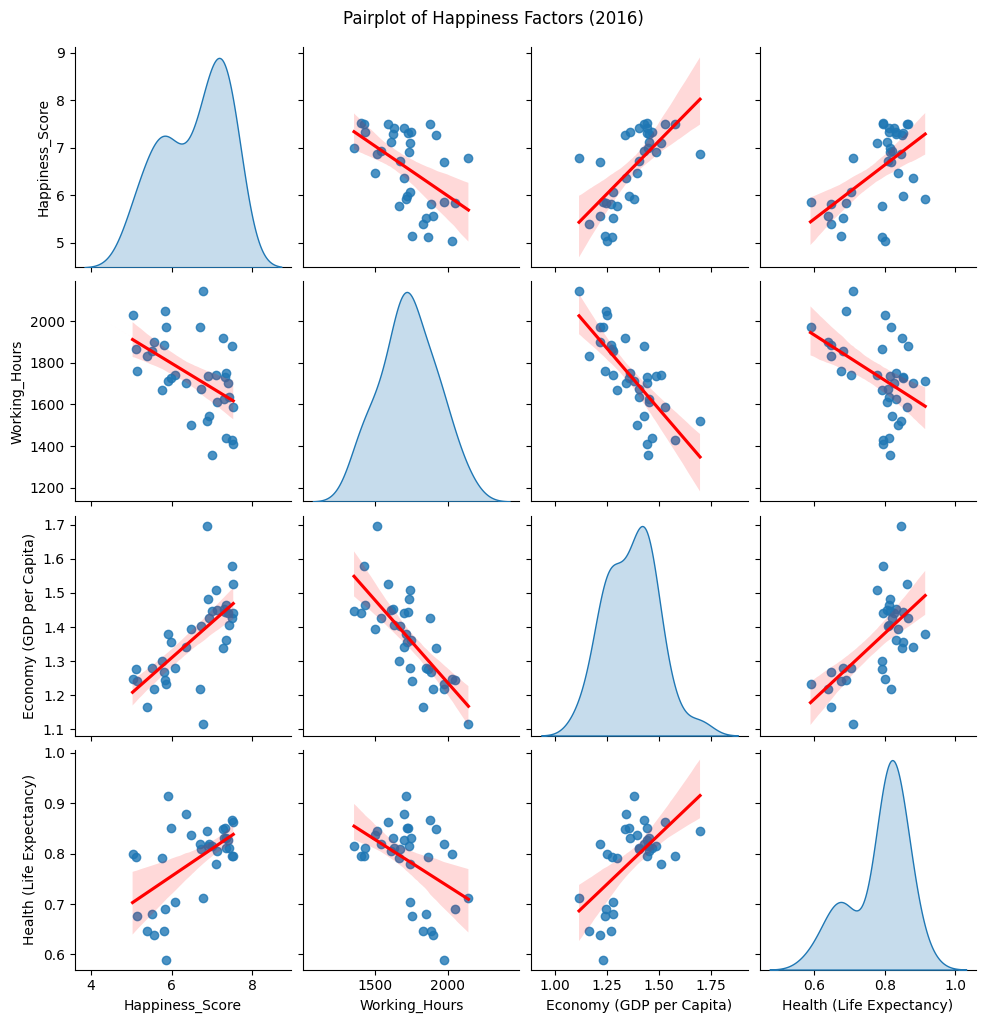

In [247]:
# trying my hand at a pairplot of key factors...this is a bit gratuitous on my part
sb.pairplot(
    merged,
    vars=[
        'Happiness_Score',
        'Working_Hours',
        'Economy (GDP per Capita)',
        'Health (Life Expectancy)'
    ],
    kind='reg',       # for the scatter + regression line
    diag_kind='kde',  # smoothed distributions
    plot_kws={'line_kws':{'color':'red'}}  # regression line in red...left it in blue originally and it was a blue blob...
)
plt.suptitle("Pairplot of Happiness Factors (2016)", y=1.02)
plt.show()

In [249]:
# now i'm gonna keep with the theme and try to generate a brief description of the pairplot
description = """This pairplot visualizes the relationships between key factors of happiness in 2016:
- Happiness_Score
- Working_Hours
- Economy (GDP per Capita)
- Health (Life Expectancy)

My Observations:
- There seems to be a negative relationship between Working Hours and Happiness Scores.
- There are positive correlations between Happiness, Economy (GDP per Capita), and Health (Life Expectancy)."""

print(description)

This pairplot visualizes the relationships between key factors of happiness in 2016:
- Happiness_Score
- Working_Hours
- Economy (GDP per Capita)
- Health (Life Expectancy)

My Observations:
- There seems to be a negative relationship between Working Hours and Happiness Scores.
- There are positive correlations between Happiness, Economy (GDP per Capita), and Health (Life Expectancy).


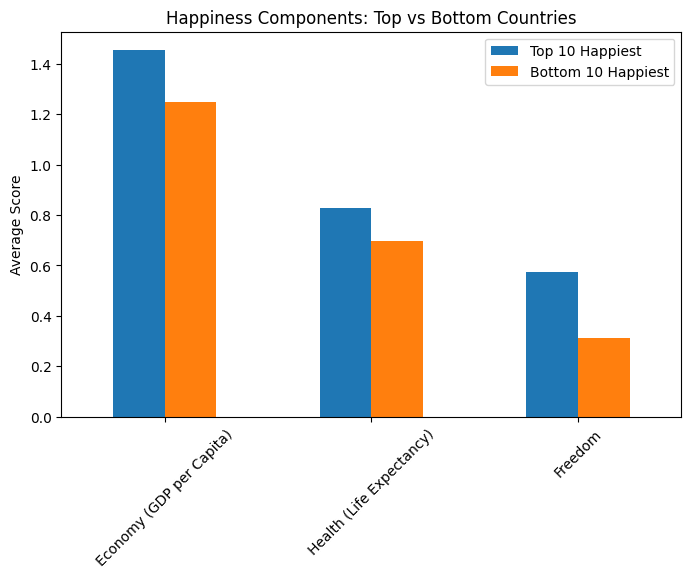

In [143]:
top = merged.sort_values('Happiness_Score', ascending=False).head(10)
bottom = merged.sort_values('Happiness_Score').head(10)

top_means = top[component_cols].mean()
bottom_means = bottom[component_cols].mean()

comparison = pd.DataFrame({
    'Top 10 Happiest': top_means,
    'Bottom 10 Happiest': bottom_means
})

comparison.plot(kind='bar', figsize=(8,5))
plt.title("Happiness Components: Top vs Bottom Countries")
plt.ylabel("Average Score")
plt.xticks(rotation=45)
plt.show()

In [252]:
print("""This bar chart compares the average scores of key happiness components between the top 10 happiest countries and the
bottom 10...or least happy countries in 2016. The top 10 happiest countries consistently score higher across all components: 
Economy ( GDP per Capita ), and Health ( Life Expectancy ), and Freedom. Trust in Government also shows a notable gap between the 
happiest and least happy countries...which definitely makes sense to me! This composite bar graph highlights how different factors 
collectively shape happiness outcomes and provides a clear contrast between nations with high and low happiness scores.

This is in line with my previous mention of multiple factors contributing as much as working hours...the World Happiness Report 
doesn't include working hours anyhow, so these are measured off of the other variables listed...it's just interesting how something
that isn't on the list still seamlessly blends with these other trends.""")

This bar chart compares the average scores of key happiness components between the top 10 happiest countries and the
bottom 10...or least happy countries in 2016. The top 10 happiest countries consistently score higher across all components: 
Economy ( GDP per Capita ), and Health ( Life Expectancy ), and Freedom. Trust in Government also shows a notable gap between the 
happiest and least happy countries...which definitely makes sense to me! This composite bar graph highlights how different factors 
collectively shape happiness outcomes and provides a clear contrast between nations with high and low happiness scores.

This is in line with my previous mention of multiple factors contributing as much as working hours...the World Happiness Report 
doesn't include working hours anyhow, so these are measured off of the other variables listed...it's just interesting how something
that isn't on the list still seamlessly blends with these other trends.


In [112]:
import sys
!{sys.executable} -m pip install pyfiglet

  Using cached pyfiglet-1.0.4-py3-none-any.whl.metadata (7.4 kB)
Using cached pyfiglet-1.0.4-py3-none-any.whl (1.8 MB)


In [148]:
from datetime import datetime
from pyfiglet import figlet_format

print(figlet_format("Happy Birthday!", font="slant"))

print("""
╔═══════════════════════════════════╗
🎂      HAPPY BIRTHDAY TO ME!      🎂
🎉 Celebrating with Python & Data! 🎉
╚═══════════════════════════════════╝
""")

from datetime import date

today = date.today()

# just for fun: printing a birthday message on presentation day
if today.month == 12 and today.day == 18:  # replace with your birthday
    print("🎉 Happy Birthday to ME Number Three! I wanted to include this really badly! 🎉")

    __  __                       
   / / / /___ _____  ____  __  __
  / /_/ / __ `/ __ \/ __ \/ / / /
 / __  / /_/ / /_/ / /_/ / /_/ / 
/_/ /_/\__,_/ .___/ .___/\__, /  
           /_/   /_/    /____/   
    ____  _      __  __        __            __
   / __ )(_)____/ /_/ /_  ____/ /___ ___  __/ /
  / __  / / ___/ __/ __ \/ __  / __ `/ / / / / 
 / /_/ / / /  / /_/ / / / /_/ / /_/ / /_/ /_/  
/_____/_/_/   \__/_/ /_/\__,_/\__,_/\__, (_)   
                                   /____/      


╔═══════════════════════════════════╗
🎂      HAPPY BIRTHDAY TO ME!      🎂
🎉 Celebrating with Python & Data! 🎉
╚═══════════════════════════════════╝



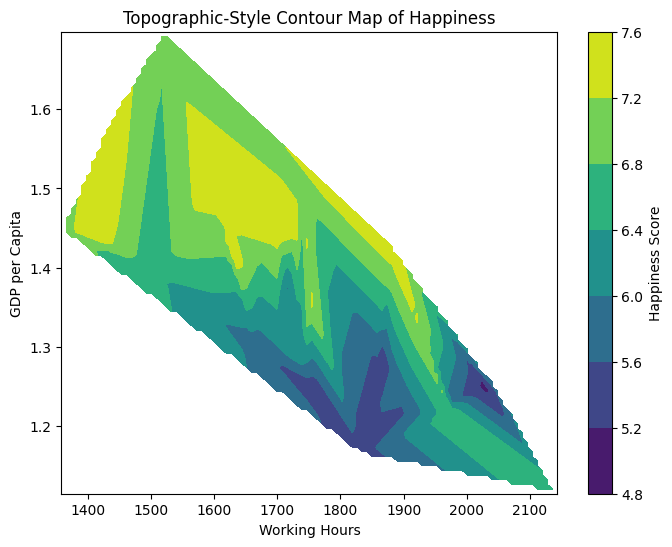

In [144]:
#  another gratuitous addition to my presentation...creating a grid...because I LOVE topographic maps
x = merged['Working_Hours']
y = merged['Economy (GDP per Capita)']
z = merged['Happiness_Score']

# creating a mesh mesh
xi = np.linspace(x.min(), x.max(), 100)
yi = np.linspace(y.min(), y.max(), 100)
xi, yi = np.meshgrid(xi, yi)

# interpolating
from scipy.interpolate import griddata
zi = griddata((x, y), z, (xi, yi), method='linear')

# plot contouring
plt.figure(figsize=(8,6))
contour = plt.contourf(xi, yi, zi, cmap='viridis')
plt.colorbar(contour, label='Happiness Score')
plt.xlabel('Working Hours')
plt.ylabel('GDP per Capita')
plt.title('Topographic-Style Contour Map of Happiness')
plt.show()

In [253]:
print("""This topographic-style contour map visualizes the relationship between Working Hours, Economy ( GDP per Capita ), and 
Happiness Scores for countries in 2016. The color gradients represent happiness levels, with brighter areas ( lime green ) indicating 
higher happiness and the darker ones ( navy and indigo ) represent lower happiness scores. This is a visually engaging approach to the data
for those who are more visual learners.""")

# I want to better understand these graphs with time ( so I can pen better analyses ), but for now...isn't it pretty?

This topographic-style contour map visualizes the relationship between Working Hours, Economy ( GDP per Capita ), and 
Happiness Scores for countries in 2016. The color gradients represent happiness levels, with brighter areas ( lime green ) indicating 
higher happiness and the darker ones ( navy and indigo ) represent lower happiness scores. This is a visually engaging approach to the data
for those who are more visual learners.


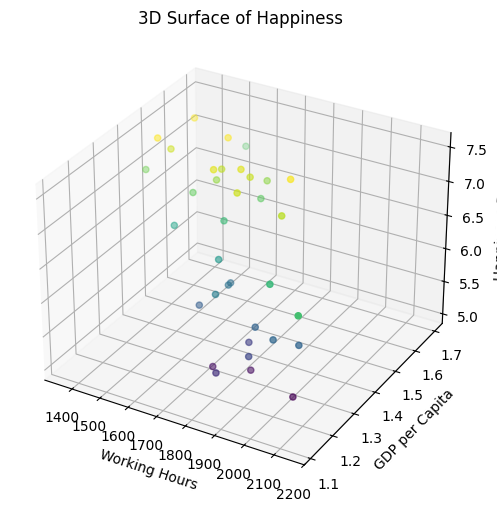

In [254]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    merged['Working_Hours'],
    merged['Economy (GDP per Capita)'],
    merged['Happiness_Score'],
    c=merged['Happiness_Score'],
    cmap='viridis'
)

ax.set_xlabel('Working Hours')
ax.set_ylabel('GDP per Capita')
ax.set_zlabel('Happiness Score')
ax.set_title('3D Surface of Happiness')

plt.show()

# I wont even try to describe this graph, it just looks super interesting...

In [154]:
print("Okay, here are some additional things that came to mind when I was doing my write up in between the code:")

Okay, here are some additional things that came to mind when I was doing my write up in between the code:


In [159]:
# i'm sorting countries by happiness because I want to focus on the happiest and least happiest to see how work hours differ!
sorted_df = merged.sort_values('Happiness_Score', ascending=False)

# this is for the top 5 happiest
top5 = sorted_df.head(5)

# this is for the bottom 5 otherwise known as the least happy
bottom5 = sorted_df.tail(5)

# this is to compare average working hours for the top ten and bottom ten
top5_hours = top5['Working_Hours'].mean()
bottom5_hours = bottom5['Working_Hours'].mean()

print(f"Top 5 happiest countries average working hours: {top5_hours:.1f}")
print(f"Bottom 5 least happy countries average working hours: {bottom5_hours:.1f}")

Top 5 happiest countries average working hours: 1589.2
Bottom 5 least happy countries average working hours: 1868.3


In [255]:
# defining thresholds
top_thresh = merged['Happiness_Score'].quantile(0.75)
bottom_thresh = merged['Happiness_Score'].quantile(0.25)

# subsets
happiest = merged[merged['Happiness_Score'] >= top_thresh]
least_happy = merged[merged['Happiness_Score'] <= bottom_thresh]

# means/averages
print("Top 25% happiest avg working hours:", happiest['Working_Hours'].mean())
print("Bottom 25% happiest avg working hours:", least_happy['Working_Hours'].mean())

Top 25% happiest avg working hours: 1618.7774894444442
Bottom 25% happiest avg working hours: 1871.7857775555556


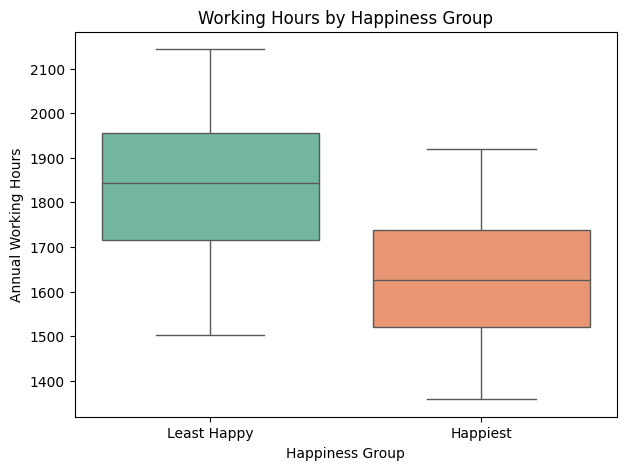

In [256]:
# creating a group label for the top and bottom countries for the box plot
merged['happiness_group'] = pd.qcut(
    merged['Happiness_Score'],
    q=2,
    labels=['Least Happy', 'Happiest']
)

plt.figure(figsize=(7,5))
sb.boxplot(
    data=merged,
    x='happiness_group',
    y='Working_Hours',
    hue='happiness_group',
    palette='Set2'
)
plt.title('Working Hours by Happiness Group')
plt.xlabel('Happiness Group')
plt.ylabel('Annual Working Hours')
plt.show()

In [257]:
print("""Thank you for following through on this slightly chaotic journey I took through this EDA! Happy Birthday to me,
and Happy Holidays to you!""")

Thank you for following through on this slightly chaotic journey I took through this EDA! Happy Birthday to me,
and Happy Holidays to you!
